# HW 16 - PyTorch
ULAB - Physics and Astronomy Division \
Due **Sunday, March 16th, 2025 at 11:59pm** on Gradescope

**Make sure to work on this notebook in DataHub!**

# 1) Recap of lecture
**Copy and paste** your code from lecture for the neural network with the **default** settings (i.e. before we improved the model). Make sure to also import the `data.py` file. 

In [19]:
import data
import matplotlib.pyplot as plt
import torch
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50), # Input layer -> Hidden layer
    torch.nn.Sigmoid(), # Activation function
    torch.nn.Linear(50, 1) # Hidden layer -> Output layer
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

What is the difference between artificial intelligence, machine learning and deep learning?

In [ ]:
# Artificial intelligence is the broadest; it encompasses systems of programming that perform tasks that involve human reasoning. Machine learning is a subset
# of that which involves having programs learn from data. And deep learning is a subset of that which involves neural networks and large amounts of data.

What is a neural network?

In [ ]:
# It's a layered system of "neurons" that predict an output given an input.

In lecture, we used `torch.nn.Linear(2, 50)`. What do the numbers `2` and `50` represent? 

In [2]:
# 2 represents the number of input features (x and y), and 50 represents the number of neurons in the hidden layer.

What does the activation function do?

In [ ]:
# It's a middle step between layers that the data gets run through before moving on to the next layer. It's non-linear. Examples include ReLU and sigmoid.

What is a loss function? Why do we need one?

In [ ]:
# A loss function calculates the "difference" between the output and the expected output. It helps the model learn because the model uses it to backpropagate and
# reduce the loss.

Why do we call `optimizer.zero_grad()` before calling `loss.backward()`?

In [ ]:
# optimizer.zero_grad() zeroes the gradient so that previous outputs don't add on to the next gradient calculation.

# 2) Modifying the Neural Network
What line do you need to modify to use **30 neurons** instead of **50**? Don't change anything else. Give the original and then modified line. 

In [3]:
"""Original line: model = torch.nn.Sequential(
    torch.nn.Linear(2, 50), # Input layer -> Hidden layer
    torch.nn.Sigmoid(), # Activation function
    torch.nn.Linear(50, 1) # Hidden layer -> Output layer
)"""
"""
New line:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 30), # 50 -> 30
    torch.nn.Sigmoid(), #  Nothing changes
    torch.nn.Linear(30, 1) # 50 -> 30
)
"""

'\nNew line:\nmodel = torch.nn.Sequential(\n    torch.nn.Linear(2, 30), # 50 -> 30\n    torch.nn.Sigmoid(), #  Nothing changes\n    torch.nn.Linear(30, 1) # 50 -> 30\n)\n'

With your default code above, run your model with **30 neurons**. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [5]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 30), # 50 -> 30
    torch.nn.Sigmoid(), #  Nothing changes
    torch.nn.Linear(30, 1) # 50 -> 30
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for t in range(1000):
    y_pred = model(data.x)            # Make a prediction
    loss = loss_fn(y_pred, data.y)    # Compare prediction to actual value
    optimizer.zero_grad()             # Reset gradients
    loss.backward()                   # Compute gradients
    optimizer.step()                   # Update model

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

# It seems like there is more loss, so the model is less accurate than if we used 50 neurons

Iteration 0, Loss: 1.0879449844360352
Iteration 100, Loss: 0.976582944393158
Iteration 200, Loss: 0.9518305659294128
Iteration 300, Loss: 0.901746392250061
Iteration 400, Loss: 0.8176854252815247
Iteration 500, Loss: 0.7085863351821899
Iteration 600, Loss: 0.5993214845657349
Iteration 700, Loss: 0.5104475617408752
Iteration 800, Loss: 0.44664856791496277
Iteration 900, Loss: 0.4019830524921417


Return to **50 neurons**. Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.ReLU`. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [6]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.ReLU(), 
    torch.nn.Linear(50, 1)
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for t in range(1000):
    y_pred = model(data.x)            # Make a prediction
    loss = loss_fn(y_pred, data.y)    # Compare prediction to actual value
    optimizer.zero_grad()             # Reset gradients
    loss.backward()                   # Compute gradients
    optimizer.step()                   # Update model

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")
# Now the model seems more accurate than the one with sigmoid because the loss function is smaller

Iteration 0, Loss: 1.2022287845611572
Iteration 100, Loss: 0.8945453763008118
Iteration 200, Loss: 0.742428183555603
Iteration 300, Loss: 0.581085205078125
Iteration 400, Loss: 0.4638979434967041
Iteration 500, Loss: 0.38783538341522217
Iteration 600, Loss: 0.34049633145332336
Iteration 700, Loss: 0.31053340435028076
Iteration 800, Loss: 0.2806476354598999
Iteration 900, Loss: 0.2519768476486206


Change your activation function from `torch.nn.Sigmoid()` to `torch.nn.Tanh`? Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [8]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Tanh(), 
    torch.nn.Linear(50, 1)
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for t in range(1000):
    y_pred = model(data.x)            # Make a prediction
    loss = loss_fn(y_pred, data.y)    # Compare prediction to actual value
    optimizer.zero_grad()             # Reset gradients
    loss.backward()                   # Compute gradients
    optimizer.step()                   # Update model

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")
# The model performed much better with Tanh instead of ReLU or sigmoid, according to the loss

Iteration 0, Loss: 1.2498977184295654
Iteration 100, Loss: 0.7812825441360474
Iteration 200, Loss: 0.5636823773384094
Iteration 300, Loss: 0.41467806696891785
Iteration 400, Loss: 0.33635810017585754
Iteration 500, Loss: 0.29097405076026917
Iteration 600, Loss: 0.25745874643325806
Iteration 700, Loss: 0.22953665256500244
Iteration 800, Loss: 0.20650406181812286
Iteration 900, Loss: 0.18668054044246674


What is the difference between `torch.nn.Sigmoid()`, `torch.nn.ReLU` and `torch.nn.Tanh`? 

In [ ]:
# They are different non-linear activation functions. Sigmoid and Tanh look relatively similar if you graph them (their ranges are different), and ReLU is a piecewise
# function that is 0 if x < 0 and x if x > 0.

Return to `torch.nn.Sigmoid()`. Change your learning rate from `1e-3` to `1e-2` in your optimizer. Compare the loss functions from lecture to your modification on the **1000th** iteration. 

In [10]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(), 
    torch.nn.Linear(50, 1)
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
for t in range(1000):
    y_pred = model(data.x)            # Make a prediction
    loss = loss_fn(y_pred, data.y)    # Compare prediction to actual value
    optimizer.zero_grad()             # Reset gradients
    loss.backward()                   # Compute gradients
    optimizer.step()                   # Update model

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")
# Now the loss is much lower than before, most likely because 1e-3 didn't allow enough steps

Iteration 0, Loss: 1.0003440380096436
Iteration 100, Loss: 0.35820645093917847
Iteration 200, Loss: 0.19802828133106232
Iteration 300, Loss: 0.13101661205291748
Iteration 400, Loss: 0.09940870851278305
Iteration 500, Loss: 0.08352755755186081
Iteration 600, Loss: 0.07395081222057343
Iteration 700, Loss: 0.06747294217348099
Iteration 800, Loss: 0.055502958595752716
Iteration 900, Loss: 0.04601535573601723


Modify your model to have **two hidden layers** instead of one. Give that code here.

In [11]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(), 
    torch.nn.Linear(50, 50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50, 1)
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
for t in range(1000):
    y_pred = model(data.x)            # Make a prediction
    loss = loss_fn(y_pred, data.y)    # Compare prediction to actual value
    optimizer.zero_grad()             # Reset gradients
    loss.backward()                   # Compute gradients
    optimizer.step()                   # Update model

    if t % 100 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")

Iteration 0, Loss: 1.0019420385360718
Iteration 100, Loss: 0.3383256793022156
Iteration 200, Loss: 0.17547845840454102
Iteration 300, Loss: 0.15815767645835876
Iteration 400, Loss: 0.12507762014865875
Iteration 500, Loss: 0.11336205154657364
Iteration 600, Loss: 0.1043303981423378
Iteration 700, Loss: 0.09629403799772263
Iteration 800, Loss: 0.09710968285799026
Iteration 900, Loss: 0.0792871043086052


# 3) More Advanced
Create a new file called `new_data.py`, make a new "hidden" function and add noise/ obscure the data (e.g. like what is done in `data.py` from lecture). Import that file here.

In [54]:
import new_data6

Define a new model and train it **poorly** in the cell below.

In [55]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 50),
    torch.nn.Sigmoid(), 
    torch.nn.Linear(50, 1)
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for t in range(100):
    y_pred = model(new_data6.x)            # Make a prediction
    loss = loss_fn(y_pred, new_data6.y)    # Compare prediction to actual value
    optimizer.zero_grad()             # Reset gradients
    loss.backward()                   # Compute gradients
    optimizer.step()                   # Update model

    if t % 10 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")
new_x = torch.linspace(0, 10, 50) # 1D array of values
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2) # Making our y, meshing them together
output_bad = model(grid).detach() # just evalutating, taking the x/y pairs and predicting a "z"
output_bad = output_bad.squeeze(2).t() # Making it the right dimension

Iteration 0, Loss: 1.2792624235153198
Iteration 10, Loss: 1.2361600399017334
Iteration 20, Loss: 1.2005531787872314
Iteration 30, Loss: 1.1702861785888672
Iteration 40, Loss: 1.1447962522506714
Iteration 50, Loss: 1.1231518983840942
Iteration 60, Loss: 1.1043347120285034
Iteration 70, Loss: 1.0874277353286743
Iteration 80, Loss: 1.0716789960861206
Iteration 90, Loss: 1.056514859199524


Improve your model and train it **well** in the cell below. (You can add more neurons, iterations, etc).

Make foure subplots (two rows, two columns). 
- (TOP LEFT) Show what the "hidden pattern" is supposed to be.
- (TOP RIGHT) Show that your "data" is.
- (BOTTOM LEFT) Show your model's prediction when you trained it poorly.
- (BOTTOM RIGHT) Show your model's prediction when you trained it well.

Iteration 0, Loss: 1.5251988172531128
Iteration 10000, Loss: 0.013004827313125134
Iteration 20000, Loss: 0.008405950851738453
Iteration 30000, Loss: 0.008022597059607506
Iteration 40000, Loss: 0.012066144496202469
Iteration 50000, Loss: 0.00795251876115799
Iteration 60000, Loss: 0.008246143348515034
Iteration 70000, Loss: 0.007784501649439335
Iteration 80000, Loss: 0.008158450946211815
Iteration 90000, Loss: 0.0075998553074896336


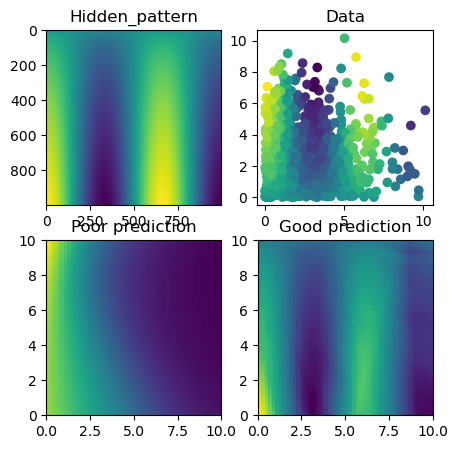

In [57]:
model = torch.nn.Sequential(
    torch.nn.Linear(2, 100),
    torch.nn.ReLU(), 
    torch.nn.Linear(100, 1)
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
for t in range(100000):
    y_pred = model(new_data6.x)            # Make a prediction
    loss = loss_fn(y_pred, new_data6.y)    # Compare prediction to actual value
    optimizer.zero_grad()             # Reset gradients
    loss.backward()                   # Compute gradients
    optimizer.step()                   # Update model

    if t % 10000 == 0:
        print(f"Iteration {t}, Loss: {loss.item()}")
new_x = torch.linspace(0, 10, 50) # 1D array of values
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2) # Making our y, meshing them together
output_good = model(grid).detach() # just evalutating, taking the x/y pairs and predicting a "z"
output_good = output_good.squeeze(2).t() # Making it the right dimension


fig, axes = plt.subplots(2, 2, figsize=(5,5))
axes[0, 0].imshow(new_data6.pattern)
axes[0, 0].set_title('Hidden_pattern')

axes[0, 1].scatter(new_data6.x_values, new_data6.y_values, c=new_data6.color_values)
axes[0, 1].set_title('Data')

axes[1, 0].imshow(output_bad, extent=(0,10,0,10))
axes[1, 0].set_title('Poor prediction')

axes[1, 1].imshow(output_good, extent=(0,10,0,10))
axes[1, 1].set_title('Good prediction')
plt.show()
# I have pytorch locally installed and a good computer so that's why im able to run so many iterations

# 4) Challenge
Find some data online and build a neural network around it. Make sure to also answer these questions:
- Where did you find your data? 
- How well does your model match your data?

In [92]:
# I found my data from the Seaborn dataset on github.
# The data matches with the dataset pretty well since the loss seems to be really low.
# My model is trying to predict how much a person will tip based on the total bill, sex, whether they're a smoker, the day, time, and the number of people at the table.
import numpy as np
import pandas as pd
df = pd.read_csv("tips.csv")
print(df)
# Reformatting data
df["sex"] = df["sex"].map({"Male": 0, "Female": 1})
df["smoker"] = df["smoker"].map({"No": 0, "Yes": 1})
df["day"] = df["day"].map({"Mon": 0, "Tue": 1, "Wed": 2, "Thur": 3, "Fri": 4, "Sat": 5, "Sun": 6})
df["time"] = df["time"].map({"Lunch": 0, "Dinner": 1})
data_tensor = torch.from_numpy(df.to_numpy().astype(np.float32))
outputs = torch.from_numpy(df.pop("tip").to_numpy().astype(np.float32))
inputs = torch.from_numpy(df.to_numpy().astype(np.float32)).squeeze()

model = torch.nn.Sequential(
    torch.nn.Linear(6, 100),
    torch.nn.ReLU(), 
    torch.nn.Linear(100, 1)
)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
num_epochs = 100
for epoch in range(num_epochs):
    for i, input_values in enumerate(inputs):
        pred = model(input_values).squeeze()
        loss = loss_fn(pred, outputs[i])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 10 == 0:
        print(f"Iteration {epoch}, Loss: {loss.item()}")
# The questions are answered at the top

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]
Iteration 0, Loss: 0.7181549668312073
Iteration 10, Loss: 0.1281307488679886
Iteration 20, Loss: 0.10576765239238739
Iteration 30, Loss: 0.08339621126651764
Iteration 40, Loss: 0.10168055444955826
Iteration 50, Loss: 0.08038831502199173
Iteration 60, Loss: 0.07199694961309433
Iteration 70, L

In [99]:
# Residuals:
print(model(inputs) - outputs)
# Example prediction on the tip if a non-smoking female paid 20 dollars for dinner on a monday with 3 other people:
print(model(torch.tensor([20, 1, 0, 0, 1, 3]).type(torch.float32)).item())

tensor([[ 1.6122,  0.9622, -0.8778,  ...,  0.6222,  0.8722, -0.3778],
        [ 1.3180,  0.6680, -1.1720,  ...,  0.3280,  0.5780, -0.6720],
        [ 1.8132,  1.1632, -0.6768,  ...,  0.8232,  1.0732, -0.1768],
        ...,
        [ 1.6723,  1.0223, -0.8177,  ...,  0.6823,  0.9323, -0.3177],
        [ 1.5506,  0.9006, -0.9394,  ...,  0.5606,  0.8106, -0.4394],
        [ 1.7274,  1.0774, -0.7626,  ...,  0.7374,  0.9874, -0.2626]],
       grad_fn=<SubBackward0>)
4.256838798522949


Once you are done, make sure to:
- Download this notebook and all releveant files (`new_data.py`, stuff from question 4, etc) from datahub.
- Move it to your **remote repository**.
- Upload to Gradescope!